## Make a copy of the workbook to edit

## Recommender Systems

Recommender systems are AI powered programs that take in a historical record about a subject (e.g. past transactions, or past preference ratings of a movie/product) and provide recommendations about that subject. 

There are two main types of recommender systems: content-based filtering and collaborative filtering. Each method has a distinct approach to making recommendations.

1. Content-Based Filtering
Content-based filtering recommends items to users based on the characteristics of the items and a user’s preferences. It analyzes the features of items (such as keywords, categories, genres, etc.) that a user has interacted with (liked, watched, purchased, etc.) and recommends similar items with similar features.

Example:

In a movie recommendation system, if a user has watched many action movies, the system will suggest other movies in the action genre. In an e-commerce platform, if a user frequently purchases sports shoes, they may be recommended similar types of shoes or sports gear.

2.  Collaborative filtering makes recommendations based on patterns of behavior and preferences from a group of users. It assumes that if users A and B have similar interests or behaviors, items that A has liked will likely be of interest to B as well. This approach leverages the thought and research that user A has put into their decisions in making recommendations to user B.

There are two main approaches to collaborative filtering:
User-based collaborative filtering: Recommends items based on similarities between users. For example, if User A has similar tastes as User B, items liked by A will be recommended to B.
Item-based collaborative filtering: Recommends items based on similarities between items. For example, if Users A and B both liked Item X, and User B also liked Item Y, Item Y might be recommended to User A.

Example:

In a music streaming service, if two users have a history of listening to similar songs, the system might recommend songs listened to by one user to the other.
On a shopping website, if users who bought a certain product also bought related items, the system will recommend those related items to other users who bought the first product.

## Association Rules

So, What is a rule?

A rule is a notation that represents which item/s is frequently bought with what item/s. A group of items is called an itemset. The rules from associative mining have a LHS and a RHS part and can be represented as follows:
itemset A => itemset B

This means, the item/s on the right (A) were frequently purchased along with items on the left (B). So for individuals who have purchased Items A, Itemset B is recommended.

How do you evaluate the strength of a rule from the data. There are three main parameters used.

- Support measures the overall popularity of an itemset.
- Confidence measures the strength of the association between two items.
- Lift measures the strength of the association while controlling for the individual popularity of the items.

More info: https://r-statistics.co/Association-Mining-With-R.html



## We are going to build recommendations based on Collaborative Filtering i.e. User Rental History

First we are going to generate a table of transactions to be used to generate recommendations. We are going to limit the number of transactions we retrieve to work within in this model because of the constraints of running these algorithms on a public infrastructure with compute/storage limits (Datacamp).

In [1]:
install.packages("fpc")
install.packages("RMySQL")

# Downloading packages -------------------------------------------------------
- Downloading fpc from CRAN ...                 OK [839.7 Kb in 0.36s]
- Downloading mclust from CRAN ...              OK [3.9 Mb in 0.36s]
- Downloading flexmix from CRAN ...             OK [1.7 Mb in 0.21s]
- Downloading prabclus from CRAN ...            OK [470 Kb in 0.2s]
- Downloading diptest from CRAN ...             OK [170.2 Kb in 0.33s]
- Downloading robustbase from CRAN ...          OK [3 Mb in 0.24s]
- Downloading DEoptimR from CRAN ...            OK [72.9 Kb in 0.18s]
- Downloading kernlab from CRAN ...             OK [1.9 Mb in 0.74s]
Successfully downloaded 8 packages in 4.4 seconds.

The following package(s) will be installed:
- DEoptimR   [1.1-3-1]
- diptest    [0.77-1]
- flexmix    [2.3-20]
- fpc        [2.2-13]
- kernlab    [0.9-33]
- mclust     [6.1.1]
- prabclus   [2.3-4]
- robustbase [0.99-4-1]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux

In [ ]:
library(fpc)
library(tidyverse)

mm <- src_mysql(
  host='[updateme]',
  port=3306,
  user='admin',
  password='[updateme]',
  dbname='dvdrental'
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“`src_mysql()` was deprecated in dplyr 1.0.0.
ℹ Please use `tbl()` directly with a database connection”


In [3]:
# Write out a query and retrieve that table from the database
query <- "
    SELECT r.customer_id, f.title AS film_rented
    FROM rental r
    JOIN inventory i ON r.inventory_id = i.inventory_id
    JOIN film f ON i.film_id = f.film_id
    ORDER BY film_rented DESC, customer_id
    LIMIT 1000"

# We are using a limit because an extremely wide data matrix will be created in later steps that cant fit in memory


df <- tbl(mm, sql(query)) %>% collect() # Get data from the database

In [4]:
tail(df)

customer_id,film_rented
<int>,<chr>
403,Velvet Terminator
424,Velvet Terminator
430,Velvet Terminator
443,Velvet Terminator
454,Velvet Terminator
464,Velvet Terminator


## Converting Transactions to a Wide Format

The next step is to convert transactions and users into a wide matrix, with users on the rows, and movies on the columns, and the value in the overlapping cell as an indication of whether a rental has happened for that individual user, for that movie. This sparse matrix is the input into the association rule mining algorithm that is being used for our collaborative filtering recommender system.

In [5]:
## convert the values into factors so that each value is distinct/unique when a matrix is created
df$film_rented <- as.factor(df$film_rented)
df$customer_id <- as.factor(df$customer_id)

# summary(df$film_rented) #you can uncomment this to see how the conversion transforms the movie data into discrete fields

In [6]:
# Count distinct customer ids in df
print("distinct customer_ids:")
n_distinct(df$customer_id) %>% print()

# Count distinct movies  in df
print("distinct films:")
n_distinct(df$film_rented) %>% print()


[1] "distinct customer_ids:"
[1] 491
[1] "distinct films:"
[1] 59


In [7]:
library(arules) #load the arules library 

df_trans <- transactions(df, format = "long", cols = c("customer_id", "film_rented"))

inspect(df_trans) #this shows us the wide format matrix more simply represented as lists. You can derive the cells that have a true value based on the movie (row) and the transaction_id (column)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘arules’


The following object is masked from ‘package:dplyr’:

    recode


The following objects are masked from ‘package:base’:

    abbreviate, write




      items                     transactionID
[1]   {Women Dorado,                         
       Youth Kick}                        1  
[2]   {Vietnam Smoochy,                      
       West Lion,                            
       Whisperer Giant}                   10 
[3]   {Virginian Pluto}                   102
[4]   {Worst Banger,                         
       Yentl Idaho}                       103
[5]   {Wait Cider}                        104
[6]   {Wrong Behavior}                    105
[7]   {Velvet Terminator,                    
       World Leathernecks}                106
[8]   {Wars Pluto,                           
       Weekend Personal}                  107
[9]   {Zorro Ark}                         108
[10]  {Wife Turn,                            
       Wolves Desire}                     109
[11]  {Wind Phantom}                      11 
[12]  {Wife Turn}                         110
[13]  {Warlock Werewolf,                     
       Women Dorado}              

In [8]:
summary(df_trans)

transactions as itemMatrix in sparse format with
 491 rows (elements/itemsets/transactions) and
 59 columns (items) and a density of 0.03365667 

most frequent items:
        Zorro Ark         Wife Turn     Witches Panic Videotape Arsenic 
               30                28                28                27 
  Virginian Pluto           (Other) 
               27               835 

element (itemset/transaction) length distribution:
sizes
  1   2   3   4   5   6   7 
208 151  86  31  10   2   3 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   2.000   1.986   3.000   7.000 

includes extended item information - examples:
             labels
1 Velvet Terminator
2 Vertigo Northwest
3   Victory Academy

includes extended transaction information - examples:
  transactionID
1             1
2            10
3           102

## Identifying the most frequently rented movies in our dataset

We will be using the ECLAT algorithm on our wide matrix (transactions object). ECLAT stands for Equivalence Class Clustering and bottom-up Lattice Traversal. It is one of the popular methods of Association Rule mining.

Breaking down the code below:

`eclat:` This is the function that applies the Eclat algorithm, a frequent itemset mining algorithm, which finds itemsets that frequently occur together in a transactional dataset.

`df_trans:` This is the input dataset, which is assumed to be in a transactional format. Typically, this is a list of transactions, where each transaction contains a set of items (e.g., a shopping basket with products).

`parameter: `A list of parameters that control the behavior of the algorithm.

`supp = 0.07:` This sets the minimum support threshold. The support is the proportion of transactions in which an itemset appears. A support of 0.07 means that we are only interested in itemsets that appear in at least 7% of the transactions.

`maxlen = 2:` This limits the maximum length of the itemsets to 2. In other words, the algorithm will only consider itemsets that contain up to 2 items.

In [9]:

# Assuming df_trans is already defined and is a transactions object
frequentItems <- eclat(df_trans, parameter = list(supp = 0.07, minlen= 1, maxlen = 3))
inspect(frequentItems)

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE    0.07      1      3 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 34 



eclat - zero frequent items




## Plotting the top movies in our dataset

Recall that are not using the entire dataset. Check the line about 'set transactions' above for the number of movies contained in this dataset. Of the movies, we are going to check the most frequently appearing movies using the `itemFrequencyPlot` function

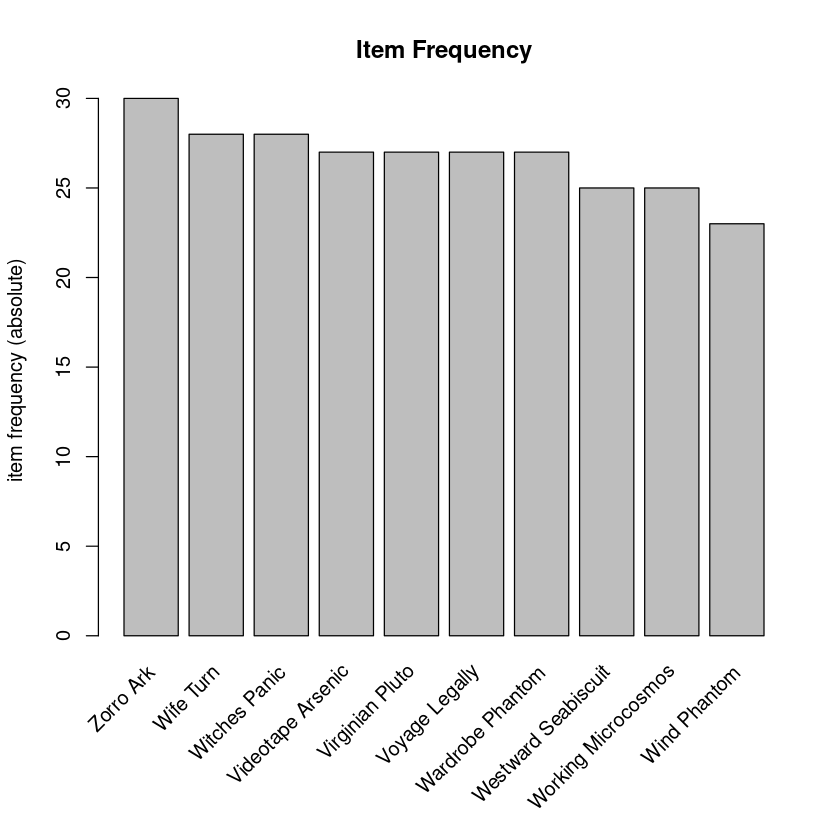

In [10]:
itemFrequencyPlot(df_trans, topN=10, type="absolute", main="Item Frequency")

## Next applying the association rules method to find recommendations

`apriori`: This function applies the Apriori algorithm, which is used for mining association rules from a dataset. Association rules help discover relationships between items in large datasets, often used for market basket analysis.

`df_trans`: This is the input dataset, assumed to be in a transactional format (each transaction contains a set of items, e.g., items in a shopping cart).
parameter: A list of parameters to control the behavior of the Apriori algorithm.

`supp = 0.001`: This sets the minimum support threshold. Support is the proportion of transactions that contain a particular itemset. A support of 0.001 means that only itemsets that appear in at least 0.1% of transactions will be considered.

`conf = 0.5`: This sets the minimum confidence threshold. Confidence is the ratio of the number of transactions containing both the antecedent and consequent of a rule to the number of transactions containing just the antecedent. A confidence of 0.5 means that the algorithm will only consider rules where at least 50% of the transactions that contain the antecedent also contain the consequent.


The output of this algorithm is rules that look like this:

    lhs   ==>  rhs                     
[1] {World Leathernecks, Wyoming Storm} => {Won Dares}

Implying that someone who rented World Leathernecks and Wyoming Storm should have Won Dares recommended to them to watch

In [11]:
rules <- apriori (df_trans, parameter = list(supp = 0.001, conf = 0.8)) # Min Support as 0.01, confidence as 0.8.
rules_conf <- sort (rules, by="confidence", decreasing=TRUE) # 'high-confidence' rules.
inspect(rules_conf) # show the support, lift and confidence for all rules

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5   0.001      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 0 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[59 item(s), 491 transaction(s)] done [0.00s].
sorting and recoding items ... [59 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 7 done [0.00s].
writing ... [2267 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
       lhs                          rhs                         support confidence   coverage     lift count
[1]    {Waterfront Deliverance,                                                                             
        Young Language}          => {Virgin Daisy}           0.0

In [12]:
rules_lift <- sort (rules, by="lift", decreasing=TRUE) # 'high-lift' rules.
inspect(head(rules_lift)) # show the support, lift and confidence for all rules

    lhs                        rhs                     support confidence   coverage     lift count
[1] {Wonderland Christmas,                                                                         
     Words Hunter}          => {Warlock Werewolf}   0.00203666          1 0.00203666 81.83333     1
[2] {Velvet Terminator,                                                                            
     Wrath Mile}            => {Watership Frontier} 0.00203666          1 0.00203666 81.83333     1
[3] {Women Dorado,                                                                                 
     Wrath Mile}            => {Watership Frontier} 0.00203666          1 0.00203666 81.83333     1
[4] {Videotape Arsenic,                                                                            
     Wrath Mile}            => {Watership Frontier} 0.00203666          1 0.00203666 81.83333     1
[5] {Velvet Terminator,                                                                            


In [13]:
inspect(rules_conf) # show the support, lift and confidence for all rules

       lhs                          rhs                         support confidence   coverage     lift count
[1]    {Waterfront Deliverance,                                                                             
        Young Language}          => {Virgin Daisy}           0.00203666          1 0.00203666 30.68750     1
[2]    {Virgin Daisy,                                                                                       
        Young Language}          => {Waterfront Deliverance} 0.00203666          1 0.00203666 28.88235     1
[3]    {Warlock Werewolf,                                                                                   
        Words Hunter}            => {Wonderland Christmas}   0.00203666          1 0.00203666 23.38095     1
[4]    {Warlock Werewolf,                                                                                   
        Wonderland Christmas}    => {Words Hunter}           0.00203666          1 0.00203666 32.73333     1
[5]    {Wonderland 

To find out what movies are influencing the recommendation of the movie Wyoming Storm

In [14]:
rules <- apriori (data=df_trans, parameter=list (supp=0.001,conf = 0.08), appearance = list (default="lhs",rhs="Wyoming Storm"), control = list (verbose=F)) # get rules that lead to renting 'Wyoming Storm'
rules_conf <- sort (rules, by="confidence", decreasing=TRUE) # 'high-confidence' rules.
inspect(rules_conf)

     lhs                      rhs                support confidence   coverage      lift count
[1]  {Wash Heavenly,                                                                          
      Won Dares}           => {Wyoming Storm} 0.00203666 1.00000000 0.00203666 37.769231     1
[2]  {Wagon Jaws,                                                                             
      West Lion}           => {Wyoming Storm} 0.00203666 1.00000000 0.00203666 37.769231     1
[3]  {Voice Peach,                                                                            
      Wagon Jaws}          => {Wyoming Storm} 0.00203666 1.00000000 0.00203666 37.769231     1
[4]  {Wagon Jaws,                                                                             
      Working Microcosmos} => {Wyoming Storm} 0.00203666 1.00000000 0.00203666 37.769231     1
[5]  {Wash Heavenly,                                                                          
      Window Side}         => {Wyoming Storm} 0.00

To find out what movies should be recommended to someone who is returning Wyoming Storm

In [15]:
rules <- apriori (data=df_trans, parameter=list (supp=0.001,conf = 0.08,minlen=2), appearance = list(default="rhs",lhs="Wyoming Storm"), control = list (verbose=F)) # those who rented 'Wyoming Storm' also rented
rules_conf <- sort (rules, by="confidence", decreasing=TRUE) # 'high-confidence' rules.
inspect(rules_conf)

    lhs                rhs                   support    confidence coverage  
[1] {Wyoming Storm} => {Wash Heavenly}       0.00610998 0.2307692  0.02647658
[2] {Wyoming Storm} => {Wagon Jaws}          0.00407332 0.1538462  0.02647658
[3] {Wyoming Storm} => {Working Microcosmos} 0.00407332 0.1538462  0.02647658
[4] {Wyoming Storm} => {Virginian Pluto}     0.00407332 0.1538462  0.02647658
    lift     count
[1] 5.150350 3    
[2] 8.393162 2    
[3] 3.021538 2    
[4] 2.797721 2    


## Content Based Filtering
This approach to building recommender systems uses more data about the films, such as ratings of the different films, film genres, and so on. You can review this post for more information on how building a recommendation system using content based filtering might work: https://www.turing.com/kb/content-based-filtering-in-recommender-systems


Other references:
- http://r-statistics.co/Association-Mining-With-R.html
- https://github.com/BrandonHoeft/Recommender-System-R-Tutorial/blob/master/RecommenderLab_Tutorial.md